In [1]:
import os, json, math, random
from pathlib import Path
from typing import Dict, Any, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import matplotlib.pyplot as plt

device = "cuda:1" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ------------------------
# Paths / dataset config
# ------------------------
DATA_ROOT = Path("./v18")
TRAIN_IMG_DIR = DATA_ROOT / "train"
VAL_IMG_DIR   = DATA_ROOT / "val"
ANN_TRAIN = TRAIN_IMG_DIR / "annotations.json"
ANN_VAL   = VAL_IMG_DIR / "annotations.json"

# ------------------------
# DINO global cluster maps (from your previous step)
# ------------------------
DINO_NAME = "dinov2_vits14"
K_REGIONS = 12  # number of predicted regions (should match global kmeans clusters ideally)

CLUSTER_MAPS_DIR = DATA_ROOT / "dino_global_clusters" / f"maps_{DINO_NAME}_k{K_REGIONS}"
assert CLUSTER_MAPS_DIR.exists(), f"Missing cluster maps dir: {CLUSTER_MAPS_DIR}"

# ------------------------
# Training config
# ------------------------
BATCH_SIZE = 16
NUM_WORKERS = 4
LR = 2e-4
EPOCHS = 20

# patch grid for ViT-S/14 at 224: 16x16
PATCH_GRID = 16
PATCH_N = PATCH_GRID * PATCH_GRID

# loss weights (tune)
W_AUX_CE     = 0.3   # pseudo-label CE (soft/aux)
W_COMPACT    = 1.0   # DINO compactness
W_SEPARATION = 0.5   # region separation
W_USAGE      = 2   # usage balance
W_SMOOTH     = 0.2   # spatial smoothness
W_ORTHO = 0.2

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


device: cuda:1


In [2]:
def load_coco_like_annotations(path: Path) -> Dict[str, Any]:
    with open(path, "r") as f:
        return json.load(f)

def build_caption_map(ann: Dict[str, Any]) -> Dict[str, str]:
    """
    Returns dict: file_stem -> caption
    Supports multiple formats:
      - COCO captions: ann["annotations"][i]["caption"] with ann["annotations"][i]["image_id"]
      - alt: "text", "sentence"
      - fallback: category list
    """
    images = ann.get("images", [])
    categories = ann.get("categories", [])
    cat_names = [c.get("name", "") for c in categories if "name" in c]
    fallback_caption = ", ".join([n for n in cat_names if n]) or "person"

    id_to_stem = {}
    for img in images:
        fn = img.get("file_name", "")
        stem = Path(fn).stem
        img_id = img.get("id", stem)
        id_to_stem[img_id] = stem

    cap_map: Dict[str, str] = {}

    # Try COCO-style captions/annotations
    anns = ann.get("annotations", [])
    for a in anns:
        img_id = a.get("image_id", None)
        cap = a.get("caption", None) or a.get("text", None) or a.get("sentence", None)
        if img_id is None or cap is None:
            continue
        stem = id_to_stem.get(img_id, None)
        if stem is not None:
            cap_map[stem] = str(cap)

    # If still empty, fill with fallback
    if len(cap_map) == 0:
        for stem in id_to_stem.values():
            cap_map[stem] = fallback_caption

    return cap_map

train_ann = load_coco_like_annotations(ANN_TRAIN)
train_caps = build_caption_map(train_ann)
print("train captions:", len(train_caps), "example:", next(iter(train_caps.items())))

val_caps = None
if ANN_VAL.exists():
    val_ann = load_coco_like_annotations(ANN_VAL)
    val_caps = build_caption_map(val_ann)
    print("val captions:", len(val_caps), "example:", next(iter(val_caps.items())))
else:
    print("No val annotations.json found; you can skip val loader.")


train captions: 6725 example: ('sequence-20250506-172443-625038-ce2df7-b3a1b450e33e4a74fbfc5e671f1d7d1ca6e184e5ad2429a2be128e63a8c80e6b-11', 'person')
val captions: 2289 example: ('sequence-20250811-160109-746626-9852a5-bf6f27428ee975d3d94669d6d18c63292f7bc01c7e03d1bd01baa4b903e9d1c2-54', 'person')


In [3]:
import os
from pathlib import Path
from typing import Dict
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

def load_npy_as_tensor(path: Path) -> torch.Tensor:
    x = np.load(path)  # (H,W) or (1,H,W)
    if x.ndim == 2:
        x = x[None, ...]  # (1,H,W)
    elif x.ndim == 3 and x.shape[0] != 1:
        # if something odd happens, keep only first channel
        x = x[:1, ...]
    x = torch.from_numpy(x).float()
    return x  # (1,H,W)

def normalize_to_minus1_1(x_1hw: torch.Tensor) -> torch.Tensor:
    x = x_1hw
    x = x - x.amin(dim=(1,2), keepdim=True)
    x = x / (x.amax(dim=(1,2), keepdim=True) + 1e-8)
    x = 2 * x - 1
    return x

def resize_pad_to_256(x_1hw: torch.Tensor, target=256) -> torch.Tensor:
    """
    Keep aspect by resizing longest side to target then center-pad to (target,target).
    """
    _, h, w = x_1hw.shape
    scale = target / max(h, w)
    nh, nw = int(round(h * scale)), int(round(w * scale))

    x = F.interpolate(
        x_1hw.unsqueeze(0),
        size=(nh, nw),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    pad_h = target - nh
    pad_w = target - nw
    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    # pad using min value to avoid artificial bright borders after normalization
    pad_val = x.min().item()
    x = F.pad(x, (left, right, top, bottom), mode="constant", value=pad_val)
    return x  # (1,256,256)

def clean_small_regions(lbl_hw: np.ndarray, min_area: int = 3, iters: int = 2) -> np.ndarray:
    """
    Simple cleanup on small grid (e.g. 16x16):
      - any label with area < min_area gets reassigned to majority label in its 8-neighborhood.
      - repeat a couple times.
    """
    lbl = lbl_hw.copy()
    H, W = lbl.shape
    for _ in range(iters):
        ids, counts = np.unique(lbl, return_counts=True)
        area = dict(zip(ids.tolist(), counts.tolist()))

        new = lbl.copy()
        for y in range(H):
            for x in range(W):
                lab = lbl[y, x]
                if area.get(lab, 0) >= min_area:
                    continue
                ys = range(max(0, y-1), min(H, y+2))
                xs = range(max(0, x-1), min(W, x+2))
                neigh = []
                for yy in ys:
                    for xx in xs:
                        neigh.append(lbl[yy, xx])
                neigh_ids, neigh_counts = np.unique(np.array(neigh), return_counts=True)
                new[y, x] = neigh_ids[np.argmax(neigh_counts)]
        lbl = new
    return lbl

class RegionTrainDataset(Dataset):
    """
    Loads:
      - image from .npy (based on annotations.json file_name)
      - cluster map from global DINO clustering (stem_clusters.npy)
      - caption from caps_map (fallback if missing)
    """
    def __init__(
        self,
        img_dir: Path,
        caps_map: Dict[str, str],
        cluster_maps_dir: Path,
        stems: list[str],
        target_size: int = 256,
    ):
        self.img_dir = img_dir
        self.caps_map = caps_map
        self.cluster_maps_dir = cluster_maps_dir
        self.stems = stems
        self.target_size = target_size

        if len(self.stems) == 0:
            raise RuntimeError("No items found after filtering. Check stems / file presence.")

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]

        npy_path = self.img_dir / f"{stem}.npy"
        if not npy_path.exists():
            raise FileNotFoundError(f"Missing image npy: {npy_path}")

        x = load_npy_as_tensor(npy_path)                # (1,H,W)
        x = resize_pad_to_256(x, target=self.target_size)
        x = normalize_to_minus1_1(x)                    # (1,256,256)

        cmap_path = self.cluster_maps_dir / f"{stem}_clusters.npy"
        if not cmap_path.exists():
            raise FileNotFoundError(f"Missing cluster map: {cmap_path}")

        lbl = np.load(cmap_path).astype(np.int64)       # (16,16)
        lbl = clean_small_regions(lbl, min_area=3, iters=2)

        cap = self.caps_map.get(stem, "person")

        return {
            "image": x,                                  # (1,256,256)
            "cluster_lbl": torch.from_numpy(lbl),        # (16,16)
            "caption": cap,
            "stem": stem,
        }
import json

def stems_from_annotations(ann_path: Path) -> list[str]:
    ann = json.loads(Path(ann_path).read_text())
    stems = []
    for img in ann.get("images", []):
        fn = img.get("file_name", "")
        stem = Path(fn).stem
        stems.append(stem)
    return stems

train_stems = stems_from_annotations(ANN_TRAIN)

# filter: require both image npy and cluster map
filtered = []
for stem in train_stems:
    npy_ok = (TRAIN_IMG_DIR / f"{stem}.npy").exists()
    cmap_ok = (CLUSTER_MAPS_DIR / f"{stem}_clusters.npy").exists()
    if npy_ok and cmap_ok:
        filtered.append(stem)

print("stems from ann:", len(train_stems))
print("filtered usable:", len(filtered))
train_ds = RegionTrainDataset(
    img_dir=TRAIN_IMG_DIR,
    caps_map=train_caps,
    cluster_maps_dir=CLUSTER_MAPS_DIR,
    stems=filtered,
    target_size=256,
)

print("train_ds:", len(train_ds))
print("example:", train_ds[0]["stem"], train_ds[0]["image"].shape, train_ds[0]["cluster_lbl"].shape, train_ds[0]["caption"])



stems from ann: 6725
filtered usable: 6725
train_ds: 6725
example: sequence-20250506-172443-625038-ce2df7-b3a1b450e33e4a74fbfc5e671f1d7d1ca6e184e5ad2429a2be128e63a8c80e6b-11 torch.Size([1, 256, 256]) torch.Size([16, 16]) person


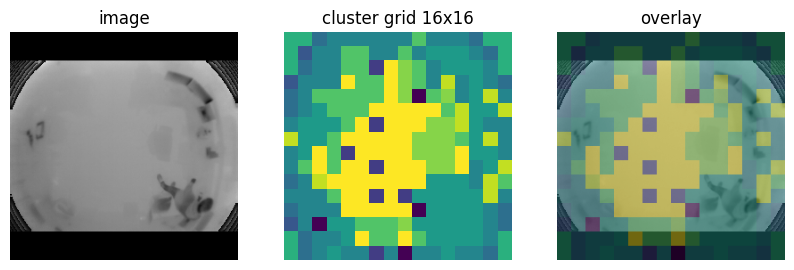

caption: person


In [4]:
def collate_fn(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)  # (B,1,256,256)
    labels = torch.stack([b["cluster_lbl"] for b in batch], dim=0)  # (B,16,16)
    caps = [b["caption"] for b in batch]
    stems = [b["stem"] for b in batch]
    return {"image": images, "cluster_lbl": labels, "caption": caps, "stem": stems}

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    collate_fn=collate_fn,
)

# Sanity plot
b = next(iter(train_loader))
img = (b["image"][0,0].cpu().numpy() + 1) / 2
lbl = b["cluster_lbl"][0].cpu().numpy()

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(lbl); plt.title("cluster grid 16x16"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(img, cmap="gray"); 
plt.imshow(np.repeat(np.repeat(lbl, 16, 0), 16, 1), alpha=0.45); plt.title("overlay"); plt.axis("off")
plt.show()

print("caption:", b["caption"][0])


In [5]:
from transformers import CLIPTokenizer, CLIPTextModel

TEXT_MODEL_NAME = "openai/clip-vit-base-patch32"

tokenizer = CLIPTokenizer.from_pretrained(TEXT_MODEL_NAME)
text_encoder = CLIPTextModel.from_pretrained(TEXT_MODEL_NAME).to(device)
text_encoder.eval()  # frozen

@torch.no_grad()
def encode_text(captions: List[str]) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Returns:
      - last_hidden_state: (B, T, C)
      - input_ids: (B, T)
    """
    tok = tokenizer(
        captions,
        padding=True,
        truncation=True,
        max_length=32,
        return_tensors="pt",
    )
    input_ids = tok.input_ids.to(device)
    attn_mask = tok.attention_mask.to(device)
    out = text_encoder(input_ids=input_ids, attention_mask=attn_mask)
    return out.last_hidden_state, input_ids


/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# DINOv2 via torch.hub (same as before)
dino = torch.hub.load("facebookresearch/dinov2", DINO_NAME).to(device)
dino.eval()

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

@torch.no_grad()
def dino_patch_tokens(x_b1_256: torch.Tensor) -> torch.Tensor:
    """
    x_b1_256: (B,1,256,256), values in [-1,1]
    returns: (B, N=256, D)
    """
    # to [0,1]
    x = (x_b1_256 + 1.0) * 0.5
    # 3ch
    x = x.repeat(1, 3, 1, 1)
    # resize to 224 for DINO patch grid (16x16)
    x = F.interpolate(x, size=(224,224), mode="bilinear", align_corners=False)
    # imagenet norm
    x = (x - IMNET_MEAN) / IMNET_STD

    out = dino.forward_features(x)
    pt = out["x_norm_patchtokens"]  # (B,256,D)
    return pt


Using cache found in /export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [7]:
class CrossAttentionBlock(nn.Module):
    """
    Queries: spatial tokens (B, N, C)
    Keys/Values: text tokens (B, T, Ct) projected to C
    Returns: updated spatial tokens + attention weights (B, heads, N, T)
    """
    def __init__(self, dim: int, text_dim: int, heads: int = 4):
        super().__init__()
        self.dim = dim
        self.heads = heads
        self.scale = (dim // heads) ** -0.5

        self.to_q = nn.Linear(dim, dim, bias=False)
        self.to_k = nn.Linear(text_dim, dim, bias=False)
        self.to_v = nn.Linear(text_dim, dim, bias=False)
        self.to_out = nn.Linear(dim, dim)

    def forward(self, x_spatial, text_tokens):
        B, N, C = x_spatial.shape
        B2, T, Ct = text_tokens.shape
        assert B == B2

        q = self.to_q(x_spatial)              # (B,N,C)
        k = self.to_k(text_tokens)            # (B,T,C)
        v = self.to_v(text_tokens)            # (B,T,C)

        # reshape heads
        h = self.heads
        q = q.view(B, N, h, C//h).transpose(1,2)  # (B,h,N,Ch)
        k = k.view(B, T, h, C//h).transpose(1,2)  # (B,h,T,Ch)
        v = v.view(B, T, h, C//h).transpose(1,2)  # (B,h,T,Ch)

        attn_logits = torch.matmul(q, k.transpose(-2, -1)) * self.scale  # (B,h,N,T)
        attn = attn_logits.softmax(dim=-1)
        out = torch.matmul(attn, v)  # (B,h,N,Ch)

        out = out.transpose(1,2).contiguous().view(B, N, C)  # (B,N,C)
        out = self.to_out(out)

        return out, attn


class RegionUNet16(nn.Module):
    """
    Input: (B,1,256,256)
    Output: logits (B,K,16,16)
    Conditioning: CLIP text tokens via cross-attention at 16x16 bottleneck
    Also returns attention weights for visualization.
    """
    def __init__(self, k_regions: int, base_ch: int = 64, text_dim: int = 512, attn_heads: int = 4):
        super().__init__()
        self.k = k_regions

        # Encoder down to 16x16 (256 -> 128 -> 64 -> 32 -> 16)
        self.enc1 = nn.Sequential(nn.Conv2d(1, base_ch, 3, padding=1), nn.GroupNorm(8, base_ch), nn.SiLU())
        self.enc2 = nn.Sequential(nn.Conv2d(base_ch, base_ch*2, 4, stride=2, padding=1), nn.GroupNorm(8, base_ch*2), nn.SiLU())
        self.enc3 = nn.Sequential(nn.Conv2d(base_ch*2, base_ch*4, 4, stride=2, padding=1), nn.GroupNorm(8, base_ch*4), nn.SiLU())
        self.enc4 = nn.Sequential(nn.Conv2d(base_ch*4, base_ch*4, 4, stride=2, padding=1), nn.GroupNorm(8, base_ch*4), nn.SiLU())
        self.enc5 = nn.Sequential(nn.Conv2d(base_ch*4, base_ch*4, 4, stride=2, padding=1), nn.GroupNorm(8, base_ch*4), nn.SiLU())

        # Cross-attention on spatial tokens (16x16 = 256 tokens)
        self.attn = CrossAttentionBlock(dim=base_ch*4, text_dim=text_dim, heads=attn_heads)

        # Decoder: keep at 16x16 and predict logits
        self.dec = nn.Sequential(
            nn.Conv2d(base_ch*4, base_ch*4, 3, padding=1),
            nn.GroupNorm(8, base_ch*4),
            nn.SiLU(),
            nn.Conv2d(base_ch*4, k_regions, 1),
        )

    def forward(self, x, text_tokens):
        # encode
        x1 = self.enc1(x)      # 256
        x2 = self.enc2(x1)     # 128
        x3 = self.enc3(x2)     # 64
        x4 = self.enc4(x3)     # 32
        x5 = self.enc5(x4)     # 16  (B,C,16,16)

        B, C, H, W = x5.shape
        spatial = x5.flatten(2).transpose(1,2)  # (B,N=256,C)

        attn_out, attn_weights = self.attn(spatial, text_tokens)  # (B,N,C), (B,h,N,T)
        spatial = spatial + attn_out

        x5c = spatial.transpose(1,2).reshape(B, C, H, W)
        logits = self.dec(x5c)  # (B,K,16,16)
        return logits, attn_weights

model = RegionUNet16(k_regions=K_REGIONS, base_ch=64, text_dim=512, attn_heads=4).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR)


In [12]:
def tv_smoothness(probs_bkhw: torch.Tensor) -> torch.Tensor:
    """
    Total-variation style smoothness on probabilities (B,K,H,W)
    """
    dy = torch.abs(probs_bkhw[:, :, 1:, :] - probs_bkhw[:, :, :-1, :]).mean()
    dx = torch.abs(probs_bkhw[:, :, :, 1:] - probs_bkhw[:, :, :, :-1]).mean()
    return dx + dy

def dino_compactness_loss(probs_bk_n, feats_b_n_d, min_mass=1e-3):
    w = probs_bk_n.clamp(min=1e-8)
    mass = w.sum(dim=2)  # (B,K)

    denom = w.sum(dim=2, keepdim=True)  # (B,K,1)
    mu = torch.matmul(w, feats_b_n_d) / denom  # (B,K,D)

    f = feats_b_n_d.unsqueeze(1)
    mu_e = mu.unsqueeze(2)
    dist2 = (f - mu_e).pow(2).sum(dim=-1)
    var = (w * dist2).sum(dim=2) / denom.squeeze(2)  # (B,K)

    # only average over regions that have enough mass
    mask = (mass > (min_mass * probs_bk_n.shape[2])).float()  # (B,K)
    return (var * mask).sum() / (mask.sum() + 1e-6)


def separation_loss_from_mu(probs_bk_n, feats_b_n_d, tau=0.2, min_mass=1e-3):
    w = probs_bk_n.clamp(min=1e-8)
    mass = w.sum(dim=2)  # (B,K)
    denom = w.sum(dim=2, keepdim=True)
    mu = torch.matmul(w, feats_b_n_d) / denom  # (B,K,D)
    mu = F.normalize(mu, dim=-1)

    B, K, D = mu.shape
    sim = torch.matmul(mu, mu.transpose(1,2))  # (B,K,K)

    # mask unused regions
    used = (mass > (min_mass * probs_bk_n.shape[2])).float()  # (B,K)
    used_pair = used.unsqueeze(2) * used.unsqueeze(1)         # (B,K,K)
    sim = sim * used_pair

    # remove diagonal
    sim = sim - torch.eye(K, device=sim.device)[None] * sim

    # penalize only used pairs
    loss = torch.exp(sim / tau) * used_pair
    return loss.sum() / (used_pair.sum() + 1e-6)


def usage_balance_loss(probs_bkhw: torch.Tensor) -> torch.Tensor:
    """
    Encourage average usage area_k to be close to uniform.
    KL(area || uniform) = sum_k area_k * log(area_k / (1/K))
    """
    B, K, H, W = probs_bkhw.shape
    area = probs_bkhw.mean(dim=(0,2,3)).clamp(1e-6)  # (K,)
    uniform = torch.full_like(area, 1.0 / K)
    kl = (area * (area.log() - uniform.log())).sum()
    return kl


def aux_ce_loss(logits_bkhw, pseudo_lbl_bhw, k):
    # logits: (B,K,H,W), pseudo: (B,H,W)
    B, K, H, W = logits_bkhw.shape
    loss = 0.0
    for b in range(B):
        y = pseudo_lbl_bhw[b].view(-1)
        counts = torch.bincount(y, minlength=k).float()
        w = (counts.sum() / (counts + 1e-6))  # inverse freq
        w = w / w.mean()                      # normalize
        loss = loss + F.cross_entropy(logits_bkhw[b:b+1], pseudo_lbl_bhw[b:b+1], weight=w, reduction="mean")
    return loss / B

def region_orthogonality_loss(probs_bkhw):
    # probs: (B,K,H,W)
    B, K, H, W = probs_bkhw.shape
    P = probs_bkhw.flatten(2)  # (B,K,N)
    P = P / (P.norm(dim=2, keepdim=True) + 1e-6)  # normalize rows
    G = torch.matmul(P, P.transpose(1,2))         # (B,K,K)
    I = torch.eye(K, device=probs_bkhw.device)[None]
    return ((G - I)**2).mean()


In [9]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

# ------------------------
# TensorBoard setup
# ------------------------
run_name = f"region_unet_{DINO_NAME}_k{K_REGIONS}_" + datetime.now().strftime("%Y%m%d_%H%M%S")
tb_logdir = Path("./runs") / run_name
tb_logdir.mkdir(parents=True, exist_ok=True)

writer = SummaryWriter(log_dir=str(tb_logdir))
print("TensorBoard logdir:", tb_logdir)


TensorBoard logdir: runs/region_unet_dinov2_vits14_k12_20260205_153718


In [10]:
import numpy as np
import torch
import torch.nn.functional as F

def _to_3ch(img_1hw: torch.Tensor) -> torch.Tensor:
    """(1,H,W) -> (3,H,W)"""
    return img_1hw.repeat(3, 1, 1)

def _img_minus1_1_to_01(img_1hw: torch.Tensor) -> torch.Tensor:
    """(1,H,W) in [-1,1] -> [0,1]"""
    return ((img_1hw + 1.0) * 0.5).clamp(0, 1)

def _upsample_label_nn(lbl_hw: torch.Tensor, target_hw=(256,256)) -> torch.Tensor:
    """
    lbl_hw: (H0,W0) integer labels
    returns: (H,W) integer labels, NN upsample
    """
    lbl = lbl_hw[None, None].float()  # (1,1,H0,W0)
    up = F.interpolate(lbl, size=target_hw, mode="nearest")
    return up[0,0].long()

def _label_to_color(lbl_hw: torch.Tensor, k: int) -> torch.Tensor:
    """
    lbl_hw: (H,W) int labels
    returns: (3,H,W) float in [0,1] using a deterministic colormap.
    No matplotlib needed.
    """
    H, W = lbl_hw.shape
    # deterministic palette
    rng = np.random.RandomState(0)
    palette = rng.rand(k, 3).astype(np.float32)  # (k,3)
    palette = torch.from_numpy(palette)          # cpu
    lbl = lbl_hw.clamp(0, k-1).cpu()
    color = palette[lbl.view(-1)].view(H, W, 3).permute(2,0,1)  # (3,H,W)
    return color.clamp(0,1)

def _overlay(img_3hw: torch.Tensor, color_3hw: torch.Tensor, alpha: float = 0.45) -> torch.Tensor:
    """
    img_3hw in [0,1], color_3hw in [0,1]
    """
    return ((1 - alpha) * img_3hw + alpha * color_3hw).clamp(0, 1)

@torch.no_grad()
def log_segmentation_preview_to_tb(
    writer,
    model,
    dataset,
    epoch: int,
    device: str,
    encode_text_fn,
    k_regions: int,
    sample_index: int = 0,
):
    """
    Logs one qualitative sample to TensorBoard at each epoch:
      - input image
      - pseudo-label map
      - predicted map
      - overlays
    """
    model.eval()
    s = dataset[sample_index]

    x = s["image"].unsqueeze(0).to(device)  # (1,1,256,256) [-1,1]
    cap = s["caption"]
    pseudo16 = s["cluster_lbl"].to(device)  # (16,16)

    # forward
    text_tokens, _ = encode_text_fn([cap])  # (1,T,C)
    logits, _ = model(x, text_tokens)       # (1,K,16,16)
    pred16 = logits.argmax(dim=1)[0]        # (16,16)

    # prep images
    img01_1hw = _img_minus1_1_to_01(x[0]).detach().cpu()     # (1,256,256)
    img01_3hw = _to_3ch(img01_1hw)                           # (3,256,256)

    pseudo256 = _upsample_label_nn(pseudo16.detach().cpu(), target_hw=(256,256))
    pred256   = _upsample_label_nn(pred16.detach().cpu(),   target_hw=(256,256))

    pseudo_color = _label_to_color(pseudo256, k=k_regions)   # (3,256,256)
    pred_color   = _label_to_color(pred256,   k=k_regions)

    over_pseudo = _overlay(img01_3hw, pseudo_color, alpha=0.45)
    over_pred   = _overlay(img01_3hw, pred_color,   alpha=0.45)

    # log to TB
    writer.add_image("preview/input_image", img01_3hw, epoch)
    writer.add_image("preview/pseudo_color", pseudo_color, epoch)
    writer.add_image("preview/pred_color", pred_color, epoch)
    writer.add_image("preview/overlay_pseudo", over_pseudo, epoch)
    writer.add_image("preview/overlay_pred", over_pred, epoch)

    # also log caption as text
    writer.add_text("preview/caption", f"epoch={epoch} | idx={sample_index} | caption={cap}", epoch)


In [13]:
@torch.no_grad()
def region_usage_stats(probs_bkhw: torch.Tensor):
    # probs: (B,K,H,W) with softmax over K
    area = probs_bkhw.mean(dim=(0,2,3))  # (K,)
    area_sum = area.sum()
    entropy = -(area.clamp(1e-6) * area.clamp(1e-6).log()).sum()
    return area, area_sum, entropy



def train_one_epoch(model, loader, opt, epoch: int, writer: SummaryWriter):
    model.train()

    running = {
        "loss": 0.0,
        "aux": 0.0,
        "compact": 0.0,
        "sep": 0.0,
        "usage": 0.0,
        "smooth": 0.0,
    }
    n = 0

    for step, batch in enumerate(tqdm(loader, desc=f"Train epoch {epoch}")):
        x = batch["image"].to(device)            # (B,1,256,256)
        pseudo = batch["cluster_lbl"].to(device) # (B,16,16)
        caps = batch["caption"]

        # ---- text encoding ----
        text_tokens, _ = encode_text(caps)

        # ---- UNet forward ----
        logits, attn_w = model(x, text_tokens)
        probs = logits.softmax(dim=1)  # (B,K,16,16)
        # with torch.no_grad():
        #     probs = logits.softmax(dim=1)  # (B,K,16,16)
        #     s = probs.sum(dim=1)           # should be all-ones (B,16,16)

        #     print("probs min/max:", probs.min().item(), probs.max().item())
        #     print("sum over K min/max:", s.min().item(), s.max().item())  # should be ~1,1

        # raise RuntimeError("Stop after one batch for code review. Remove this after checking the forward pass and losses.")


        # ---- DINO features ----
        with torch.no_grad():
            feats = dino_patch_tokens(x)          # (B,256,D)

        probs_bk_n = probs.flatten(2)              # (B,K,256)

        # ---- losses ----
        L_aux = aux_ce_loss(logits, pseudo, k=K_REGIONS)
        L_comp = dino_compactness_loss(probs_bk_n, feats)
        L_sep  = separation_loss_from_mu(probs_bk_n, feats)
        L_use  = usage_balance_loss(probs)
        L_sm   = tv_smoothness(probs)
        L_ortho = region_orthogonality_loss(probs)

        loss = (
            W_AUX_CE     * L_aux +
            W_COMPACT    * L_comp +
            W_SEPARATION * L_sep +
            W_USAGE      * L_use +
            W_SMOOTH     * L_sm + 
            W_ORTHO      * L_ortho
        )

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        # ---- accumulate ----
        running["loss"]    += loss.item()
        running["aux"]     += L_aux.item()
        running["compact"] += L_comp.item()
        running["sep"]     += L_sep.item()
        running["usage"]   += L_use.item()
        running["smooth"]  += L_sm.item()
        n += 1

    # ---- epoch averages ----
    for k in running:
        running[k] /= max(1, n)

    # ---- TensorBoard logging (epoch-level) ----
    writer.add_scalar("train/loss_total", running["loss"], epoch)
    writer.add_scalar("train/loss_aux_ce", running["aux"], epoch)
    writer.add_scalar("train/loss_compactness", running["compact"], epoch)
    writer.add_scalar("train/loss_separation", running["sep"], epoch)
    writer.add_scalar("train/loss_usage", running["usage"], epoch)
    writer.add_scalar("train/loss_smoothness", running["smooth"], epoch)

    # learning rate
    lr = opt.param_groups[0]["lr"]
    writer.add_scalar("train/lr", lr, epoch)

        # after the training loop, before return
    area, area_sum, ent = region_usage_stats(probs)

    writer.add_scalar("train/region_usage/sum", area_sum.item(), epoch)   # should be ~1.0
    writer.add_scalar("train/region_usage/entropy", ent.item(), epoch)    # max ~ log(K)

    for k_i, v in enumerate(area):
        writer.add_scalar(f"train/region_usage/r{k_i}", v.item(), epoch)



    return running

for epoch in range(1, EPOCHS+1):
    if epoch <= 3:
        W_AUX_CE = 1.0
        W_USAGE = 2.0
        W_SEPARATION = 0.2
    else:
        W_AUX_CE = 0.2
        W_USAGE = 1.0
        W_SEPARATION = 0.5

    stats = train_one_epoch(model, train_loader, opt, epoch, writer)
    # qualitative preview
    log_segmentation_preview_to_tb(
        writer=writer,
        model=model,
        dataset=train_ds,
        epoch=epoch,
        device=device,
        encode_text_fn=encode_text,
        k_regions=K_REGIONS,
    )
    print(stats)


Train epoch 1: 100%|██████████| 420/420 [01:16<00:00,  5.50it/s]


{'loss': 768.6973678588868, 'aux': 8.122733959697541, 'compact': 742.7442430768695, 'sep': 73.46671923285439, 'usage': 1.5107729583490817, 'smooth': 0.03495918460678132}


Train epoch 2: 100%|██████████| 420/420 [01:15<00:00,  5.55it/s]


{'loss': 828.6445287068685, 'aux': 9.51086006391616, 'compact': 802.7833770751953, 'sep': 63.822828658138, 'usage': 1.733548935963994, 'smooth': 0.02649022185674507}


Train epoch 3: 100%|██████████| 420/420 [01:10<00:00,  5.98it/s]


...

{'loss': 139.78376017979213, 'aux': 12.346817259561448, 'compact': 111.54452801658994, 'sep': 47.02307600293841, 'usage': 2.250605152902149, 'smooth': 0.015265468911578258}


Train epoch 19: 100%|██████████| 420/420 [01:14<00:00,  5.66it/s]


{'loss': 137.99927676972888, 'aux': 12.373995056606475, 'compact': 110.04327792213077, 'sep': 46.45268169584728, 'usage': 2.247160198007311, 'smooth': 0.015432691441050597}


Train epoch 20: 100%|██████████| 420/420 [01:15<00:00,  5.60it/s]


{'loss': 134.27813836960564, 'aux': 12.262054665883381, 'compact': 107.01679111662365, 'sep': 45.12458245413644, 'usage': 2.2400225321451823, 'smooth': 0.015901729823755366}


In [ ]:
@torch.no_grad()
def visualize_attention_for_sample(model, dataset: Dataset, idx: int, max_tokens: int = 10):
    model.eval()
    sample = dataset[idx]
    x = sample["image"].unsqueeze(0).to(device)    # (1,1,256,256)
    cap = sample["caption"]
    stem = sample["stem"]

    text_tokens, input_ids = encode_text([cap])    # (1,T,512), (1,T)

    logits, attn = model(x, text_tokens)           # attn: (1,h,N,T)
    attn = attn[0]                                 # (h,N,T)
    attn = attn.mean(dim=0)                         # (N,T) avg heads
    attn = attn.reshape(PATCH_GRID, PATCH_GRID, -1) # (16,16,T)

    # decode tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

    # image for plotting
    img = ((x[0,0].cpu().numpy() + 1) / 2).clip(0,1)

    # pick tokens to show (skip special tokens)
    show = []
    for ti, tok in enumerate(tokens):
        if tok in ["<|startoftext|>", "<|endoftext|>", tokenizer.pad_token]:
            continue
        if tok.startswith("Ġ") or tok.startswith("▁"):
            tok_disp = tok[1:]
        else:
            tok_disp = tok
        if tok_disp.strip() == "":
            continue
        show.append((ti, tok_disp))
        if len(show) >= max_tokens:
            break

    cols = 5
    rows = math.ceil(len(show)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3.2*cols, 3.2*rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, (ti, tok_disp) in enumerate(show):
        heat = attn[:,:,ti].cpu().numpy()
        heat_up = np.repeat(np.repeat(heat, 16, axis=0), 16, axis=1)  # 16x16 -> 256x256
        heat_up = (heat_up - heat_up.min()) / (heat_up.max() - heat_up.min() + 1e-8)

        ax = axes[i]
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.imshow(heat_up, alpha=0.55)  # default colormap
        ax.set_title(tok_disp)

    plt.suptitle(f"Stem={stem}\nCaption={cap}", y=1.02)
    plt.tight_layout()
    plt.show()

# Try a few
visualize_attention_for_sample(model, train_ds, idx=0, max_tokens=12)
visualize_attention_for_sample(model, train_ds, idx=len(train_ds)//2, max_tokens=12)


In [ ]:
@torch.no_grad()
def visualize_prediction(model, dataset: Dataset, idx: int):
    model.eval()
    s = dataset[idx]
    x = s["image"].unsqueeze(0).to(device)
    cap = s["caption"]
    stem = s["stem"]
    pseudo = s["cluster_lbl"].cpu().numpy()

    text_tokens, _ = encode_text([cap])
    logits, _ = model(x, text_tokens)
    pred = logits.argmax(dim=1)[0].cpu().numpy()  # (16,16)

    img = ((x[0,0].cpu().numpy() + 1) / 2).clip(0,1)
    pred_up = np.repeat(np.repeat(pred, 16, 0), 16, 1)
    pseudo_up = np.repeat(np.repeat(pseudo, 16, 0), 16, 1)

    plt.figure(figsize=(12,3))
    plt.subplot(1,4,1); plt.imshow(img, cmap="gray"); plt.title("image"); plt.axis("off")
    plt.subplot(1,4,2); plt.imshow(pseudo); plt.title("pseudo 16x16"); plt.axis("off")
    plt.subplot(1,4,3); plt.imshow(pred); plt.title("pred 16x16"); plt.axis("off")
    plt.subplot(1,4,4); 
    plt.imshow(img, cmap="gray"); plt.imshow(pred_up, alpha=0.45); plt.title("overlay pred"); plt.axis("off")
    plt.suptitle(f"{stem}\n{cap}", y=1.05)
    plt.tight_layout()
    plt.show()

visualize_prediction(model, train_ds, 0)
visualize_prediction(model, train_ds, len(train_ds)//3)


In [ ]:
@torch.no_grad()
def pseudo_label_stats(dataset, n=256):
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    all_area = []
    for i in idxs:
        lbl = dataset[i]["cluster_lbl"].numpy()  # (16,16)
        ids, counts = np.unique(lbl, return_counts=True)
        area = np.zeros(K_REGIONS, dtype=np.float32)
        area[ids] = counts / counts.sum()
        all_area.append(area)
    all_area = np.stack(all_area, axis=0)  # (n,K)
    mean_area = all_area.mean(axis=0)
    print("mean pseudo area:", mean_area)
    print("max mean area:", mean_area.max(), "argmax:", mean_area.argmax())
    print("mean entropy:", (- (all_area * np.log(all_area + 1e-8)).sum(axis=1)).mean())
    return mean_area

mean_area = pseudo_label_stats(train_ds, n=512)

mean pseudo area: [0.10123444 0.05066681 0.04715729 0.02128601 0.05393982 0.17156982
 0.16501617 0.0405426  0.07082367 0.06548309 0.06578827 0.146492  ]
max mean area: 0.17156982 argmax: 5
mean entropy: 2.0448809
